In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import sys
import os
os.chdir('/home/jif564/bancpipeline/analysis/python/')
import cascade_model
#from cascade_model import SignalCascade
import igraph as ig

#### Toy dataset design

In [2]:
# 1. Create toy edge list (synaptic connections)
def create_toy_edges(n_neurons=50, n_connections=200):
    """
    Create toy edge list with:
    - source_neuron: ID of presynaptic neuron
    - target_neuron: ID of postsynaptic neuron
    - n_synapses: number of synapses in this connection
    """
    # Generate random connections
    sources = np.random.randint(0, n_neurons, n_connections)
    targets = np.random.randint(0, n_neurons, n_connections)
    
    # Ensure no self-loops
    valid_connections = sources != targets
    sources = sources[valid_connections]
    targets = targets[valid_connections]
    
    # Generate synapse counts (mostly small numbers, some larger ones)
    n_synapses = np.random.exponential(2, len(sources)).astype(int) + 1
    
    edges_df = pd.DataFrame({
        'source_neuron': sources,
        'target_neuron': targets,
        'n_synapses': n_synapses
    })
    
    # Remove duplicates and sum synapse counts
    edges_df = edges_df.groupby(['source_neuron', 'target_neuron'])['n_synapses'].sum().reset_index()
    
    return edges_df

# 2. Create toy neuron metadata
def create_toy_metadata(n_neurons=50):
    """
    Create toy metadata with:
    - neuron_id: unique identifier
    - neuron_type: sensory, interneuron, MB, or output
    - class: more specific classification
    """
    neuron_ids = np.arange(n_neurons)
    
    # Assign neuron types (with realistic proportions)
    n_sensory = n_neurons // 10  # 10% sensory
    n_mb = n_neurons // 5      # 20% mushroom body
    n_output = n_neurons // 10  # 10% output
    n_inter = n_neurons - (n_sensory + n_mb + n_output)  # rest are interneurons
    
    neuron_types = (
        ['sensory'] * n_sensory +
        ['MB'] * n_mb +
        ['output'] * n_output +
        ['interneuron'] * n_inter
    )
    
    # Create more specific classes
    classes = []
    for ntype in neuron_types:
        if ntype == 'sensory':
            classes.append(np.random.choice(['olfactory', 'visual', 'gustatory']))
        elif ntype == 'MB':
            classes.append(np.random.choice(['KC', 'MBON', 'DAN']))
        elif ntype == 'output':
            classes.append(np.random.choice(['DN_VNC', 'DN_SEZ', 'RGN']))
        else:
            classes.append('interneuron')
    
    metadata_df = pd.DataFrame({
        'neuron_id': neuron_ids,
        'neuron_type': neuron_types,
        'class': classes
    })
    
    return metadata_df

# 3. Convert edge list to connectivity matrix
def create_connectivity_matrix(edges_df, n_neurons):
    """
    Convert edge list to adjacency matrix
    """
    connectivity_matrix = np.zeros((n_neurons, n_neurons))
    for _, row in edges_df.iterrows():
        connectivity_matrix[row['source_neuron'], row['target_neuron']] = row['n_synapses']
    return connectivity_matrix



#### Toy data creation and visualization

In [3]:
# Create toy dataset
N_NEURONS = 50
edges_df = create_toy_edges(N_NEURONS)
metadata_df = create_toy_metadata(N_NEURONS)
connectivity_matrix = create_connectivity_matrix(edges_df, N_NEURONS)

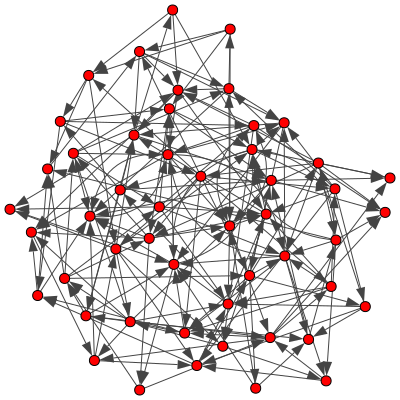

In [4]:
# igraph
#subset_df = fw_elistf.sample(n=50000)
g = ig.Graph.TupleList(edges_df[['source_neuron', 'target_neuron']].itertuples(index=False), directed=True)


# Add weights if present
if 'n_synapses' in edges_df.columns:
    g.es['n_synapses'] = edges_df['n_synapses'].tolist()

# Visualize the subgraph
layout = g.layout("kk")  # Kamada-Kawai layout for visualization
ig.plot(g, layout=layout, vertex_size=10, bbox=(400, 400), margin=10)

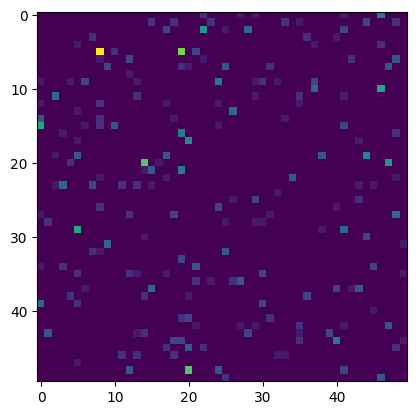

In [5]:
plt.imshow(connectivity_matrix)

In [10]:
# Example of how to use with the SignalCascade model
def run_example_analysis():
    # Initialize the cascade model
    cascade = cascade_model.SignalCascade()
    
    # Get neuron sets from metadata
    sensory_neurons = set(metadata_df[metadata_df['neuron_type'] == 'sensory']['neuron_id'])
    mb_neurons = set(metadata_df[metadata_df['neuron_type'] == 'MB']['neuron_id'])
    
    # Run cascade
    result_dict = cascade.run_cascade(
        S_A0=sensory_neurons,
        S_E=mb_neurons,
        connectivity_matrix=connectivity_matrix,
        max_timesteps=4
    )
    activation_probs = result_dict['probabilities']
    source_mask = result_dict['source_neurons']
    end_mask = result_dict['end_neurons']
    # Analyze pathways
    pathways = cascade.analyze_pathways(activation_probs)
    
    return result_dict, pathways





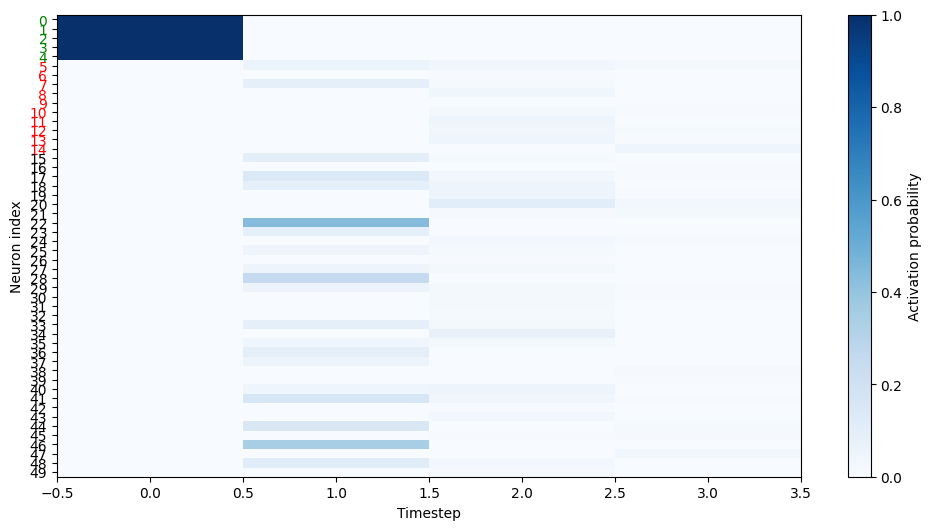


Network statistics:
Total neurons: 50
Total connections: 192
Average synapses per connection: 2.67

Neuron type distribution:
neuron_type
interneuron    30
MB             10
sensory         5
output          5
Name: count, dtype: int64


In [11]:
# Example of how the data looks
#print("\nEdge list sample:")
#print(edges_df.head())
#print("\nMetadata sample:")
#print(metadata_df.head())
#print("\nConnectivity matrix shape:", connectivity_matrix.shape)

# Run analysis
result_dict, pathways = run_example_analysis()

# Basic visualization

cascade_model.plot_cascade_results(result_dict)
# Print some statistics
print("\nNetwork statistics:")
print(f"Total neurons: {N_NEURONS}")
print(f"Total connections: {len(edges_df)}")
print(f"Average synapses per connection: {edges_df['n_synapses'].mean():.2f}")
print("\nNeuron type distribution:")
print(metadata_df['neuron_type'].value_counts())